   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 45.2 MB/s eta 0:00:00
Mounted at /content/drive
⚠️ Supabase connection failed, loading from Google Drive instead.
Error: (psycopg2.OperationalError) connection to server at "db.nokwwamsdpraxcslluzv.supabase.co" (2600:1f16:1cd0:3310:b49f:f8d3:f06a:58e2), port 5432 failed: Cannot assign requested address
	Is the server running on that host and accepting TCP/IP connections?

(Background on this error at: https://sqlalche.me/e/20/e3q8)
Loaded artifacts successfully.
Daily shape: (731, 6)


,model,mae,smape
0,naive_lag7,1.261150e+06,45.278264
1,lightgbm,2.578345e+06,627.892265


{'Total Revenue': '$1,482,231,228.74',
 'Average daily': '13.47',
 'Date range': '2023-05-27 to 2025-05-26',
 'Evaluation metric (best)': {'model': 'naive_lag7',
  'mae': 1261150.1378571428,
  'smape': 45.27826385466431}}

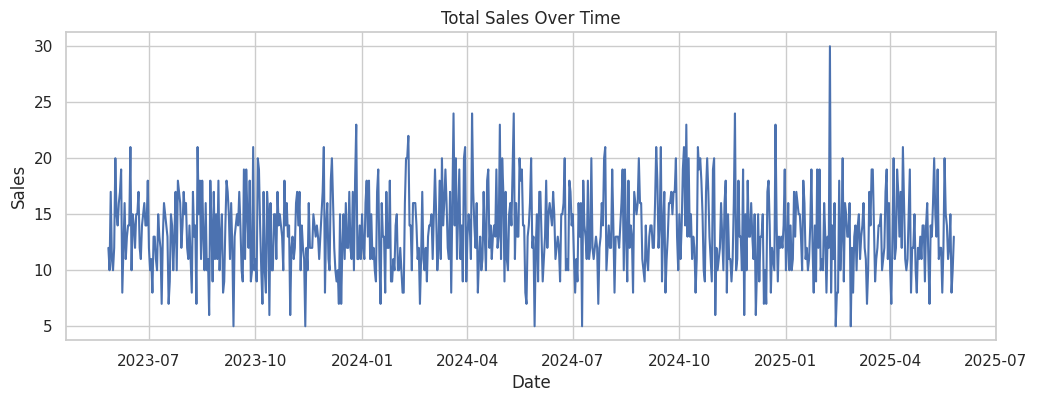

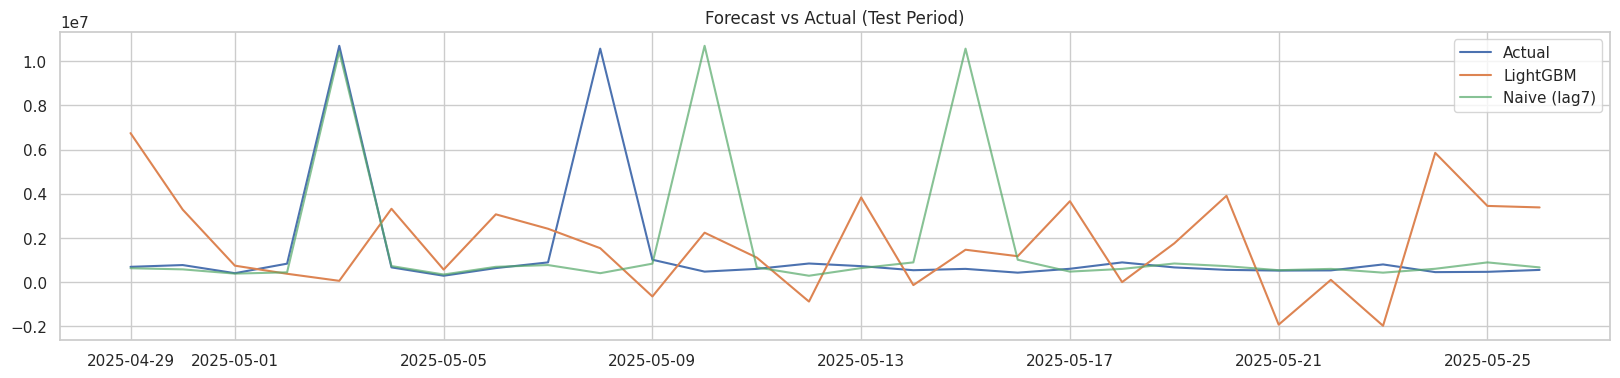

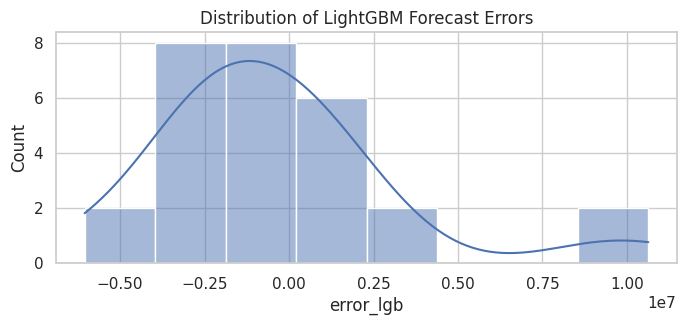

⚠️ No feature_importances_ on loaded model object.
Notebook 6 complete — Deployment Results are finished!


In [ ]:
# ============================================================
# Part 1 - Setup + Mount Google Drive
# ============================================================
!pip install --quiet sqlalchemy psycopg2-binary

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from IPython.display import display

sns.set(style="whitegrid")

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_BASE = '/content/drive/MyDrive/colab_data'
except:
    DRIVE_BASE = '/content'
os.makedirs(DRIVE_BASE, exist_ok=True)

# ============================================================
# Cell 2 - Load artifacts (Try Supabase first, fallback to Drive)
# ============================================================

DB_USER = "postgres"
DB_PASS = "retailcastcap"
DB_HOST = "db.nokwwamsdpraxcslluzv.supabase.co"
DB_PORT = "5432"
DB_NAME = "postgres"

conn_str = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

try:
    engine = create_engine(conn_str, pool_pre_ping=True)
    with engine.connect() as conn:
        print("Connected to Supabase successfully.")
        daily = pd.read_sql("SELECT * FROM clean.daily_sales_for_modeling;", conn, parse_dates=['sales_date'])
        metrics = pd.read_sql("SELECT * FROM clean.model_metrics;", conn)
        forecast = pd.read_sql("SELECT * FROM clean.forecast_results;", conn)
except Exception as e:
    print("⚠️ Supabase connection failed, loading from Google Drive instead.")
    print("Error:", e)

    daily_path = os.path.join(DRIVE_BASE, 'daily_sales_for_modeling.csv')
    metrics_path = os.path.join(DRIVE_BASE, 'model_metrics.csv')
    forecast_path = os.path.join(DRIVE_BASE, 'forecast_results.csv')

    daily = pd.read_csv(daily_path, parse_dates=['sales_date'])
    metrics = pd.read_csv(metrics_path)
    forecast = pd.read_csv(forecast_path, parse_dates=['sales_date'])

print("Loaded artifacts successfully.")
print("Daily shape:", daily.shape)
display(metrics)

# ============================================================
# Part 3 - Key summary APIs
# ============================================================

total_revenue = daily['sales_amount'].sum() if 'sales_amount' in daily.columns else daily.iloc[:, 1].sum()
avg_daily = daily.iloc[:, 1].mean()
date_min, date_max = daily['sales_date'].min(), daily['sales_date'].max()
kpis = {
    'Total Revenue': f"${total_revenue:,.2f}",
    'Average daily': f"{avg_daily:,.2f}",
    'Date range': f"{date_min.date()} to {date_max.date()}",
    'Evaluation metric (best)': metrics.loc[metrics['mae'].idxmin()].to_dict()
}
display(kpis)

# ============================================================
# Part 4 - Trend plot for total sales
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(daily['sales_date'], daily.iloc[:, 1])
plt.title("Total Sales Over Time")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.show()

# ============================================================
# Part 5 - Forecast vs actual
# ============================================================

plt.figure(figsize=(20, 4))
plt.plot(forecast['sales_date'], forecast['actual'], label='Actual')
plt.plot(forecast['sales_date'], forecast['pred_lgb'], label='LightGBM')
plt.plot(forecast['sales_date'], forecast['pred_naive'], label='Naive (lag7)', alpha=0.7)
plt.legend(); plt.title("Forecast vs Actual (Test Period)")
plt.show()

# ============================================================
# Part 6 - Error distribution
# ============================================================

forecast['error_lgb'] = forecast['actual'] - forecast['pred_lgb']
plt.figure(figsize=(8, 3))
sns.histplot(forecast['error_lgb'], kde=True)
plt.title("Distribution of LightGBM Forecast Errors")
plt.show()

# ============================================================
# Part 7 - Feature importance
# ============================================================

from joblib import load
model_path = os.path.join(DRIVE_BASE, 'lgb_model_v1.joblib')

try:
    mdl = load(model_path)
    fi = getattr(mdl, 'feature_importances_', None)
    if fi is not None:
        fi_df = pd.DataFrame({'feature': ['lag_1', 'lag_7', 'lag_14', 'roll_7', 'roll_30'], 'importance': fi})
        fi_df = fi_df.sort_values('importance', ascending=False)
        plt.figure(figsize=(8, 3))
        sns.barplot(x='importance', y='feature', data=fi_df)
        plt.title("Feature Importance (LightGBM)")
        plt.show()
    else:
        print("⚠️ No feature_importances_ on loaded model object.")
except Exception as e:
    print("⚠️ Could not load model for feature importance:", e)

print("Notebook 6 complete — Deployment Results are finished!")
